#embedding space visualization during training 


In this notebook, we run an intensive training loop on the Europarl dataset. Every few epochs, we will freeze the network, extract its massive multi-dimensional `Embedding` matrix, and use **Principal Component Analysis (PCA)** to make it 2d

the vocabulary pushes itself to side to ovoid overlapping when noise hits it

In [1]:
%matplotlib inline
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.data_loader import EuroparlDataLoader
from src.tokenizer import SemanticTokenizer
from src.model import JointSemanticModel

print("Loaded")

Loaded


### data load
3000 sentences from europarl dataset

In [2]:
data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=3000)
loader.scan_and_load()

if len(loader.all_sentences) == 0:
    print("no dta set found , training on dummy")
    sentences = ["the quick brown fox jumps over the lazy dog"] * 500
else:
    sentences = loader.all_sentences

tokenizer = SemanticTokenizer(min_freq=2)
tokenizer.fit(sentences)

print(f"Loaded {len(sentences)} sentences. vocab size {tokenizer.vocab_size}")

class SemanticDataset(Dataset):
    def __init__(self, sents, tok, max_l=15):
        self.sents = sents
        self.tok = tok
        self.max_l = max_l
    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        return torch.tensor(self.tok.encode(self.sents[idx], max_length=self.max_l), dtype=torch.long)

dataset = SemanticDataset(sentences, tokenizer, max_l=15)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Scanning dataset to build vocabulary...
dictionary size: 6617
Loaded 2945 sentences. vocab size 6617


### Step 2: The Training Loop with PCA Snapshots
We will train the model for **25 Epochs**. At Epoch 0, 5, 15, and 24, we will extract the model's `Embedding` weights and save them.

In [3]:
model = JointSemanticModel(vocab_size=tokenizer.vocab_size, embed_dim=32, hidden_dim=64, snr_db=5.0)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.PAD_ID)

epochs = 25
snapshots = {}
snapshot_epochs = [0, 5, 15, 24]

print(f"started")
for epoch in range(epochs):
    
    if epoch in snapshot_epochs:
        embeddings = model.encoder.embedding.weight.detach().numpy()
        snapshots[epoch] = embeddings.copy()

    model.train()
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()
        outputs = model(batch, batch)
        outputs_flat = outputs[:, :-1, :].reshape(-1, tokenizer.vocab_size)
        targets_flat = batch[:, 1:].reshape(-1)
        
        loss = criterion(outputs_flat, targets_flat)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1} | Average Loss: {total_loss/len(dataloader):.4f}")
        
embeddings = model.encoder.embedding.weight.detach().numpy()
snapshots[24] = embeddings.copy()
print("Training Complete!")

started
Epoch 5 | Average Loss: 5.0953
Epoch 10 | Average Loss: 4.3705
Epoch 15 | Average Loss: 3.8049
Epoch 20 | Average Loss: 3.3663
Epoch 25 | Average Loss: 3.0203
Training Complete!


###visualization
We apply PCA to reduce the 32-dimensional embedding space down to 2 dimensions so we can plot it on an X/Y

Notice how at **Epoch 0**, all the words are clustered together in a dense central blob. The noise from the `AWGNChannel` easily overlaps them, causing hallucinations.

As training progresses, the neural network learns to physically **push the word vectors away from each other** in space. This guarantees that even if a word is hit with heavy noise , it wont enter the boundaries of other wwords

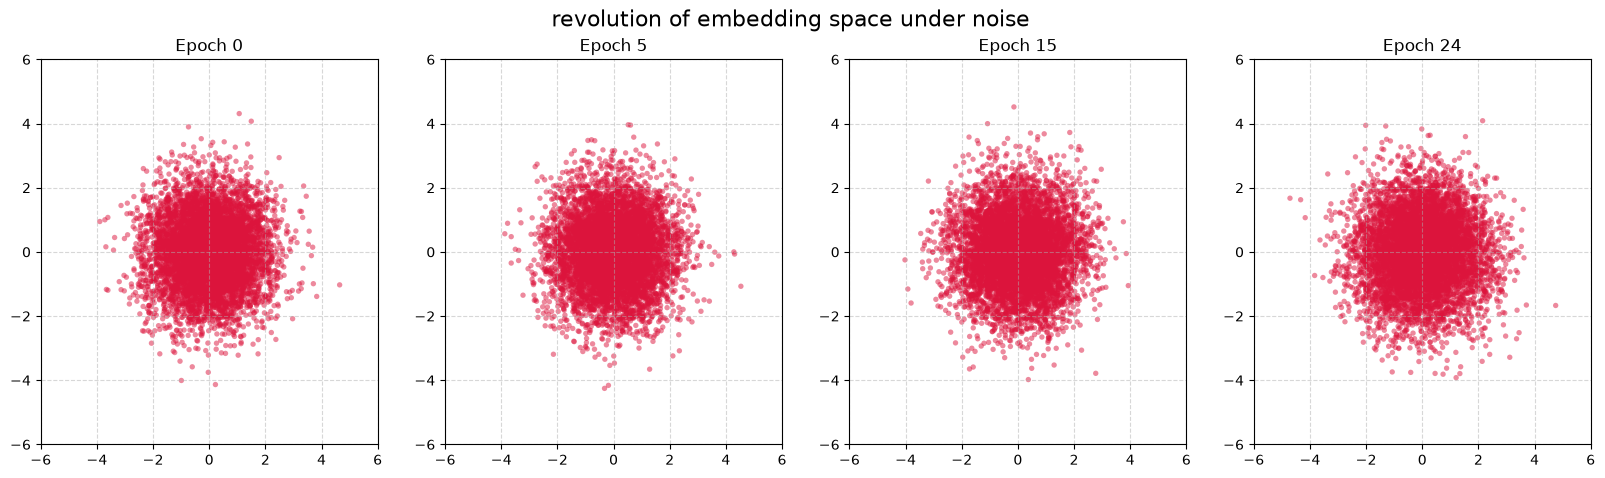

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("revolution of embedding space under noise", fontsize=16)

for i, ep in enumerate(snapshot_epochs):
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(snapshots[ep])
    
    # We ignore the first 4 tokens (PAD, UNK, BOS, EOS)
    axes[i].scatter(reduced_embeddings[4:, 0], reduced_embeddings[4:, 1], color='crimson', alpha=0.5, edgecolors='none', s=15)
    axes[i].set_title(f"Epoch {ep}")
    axes[i].grid(True, linestyle='--', alpha=0.5)
    
    axes[i].set_xlim(-6, 6)
    axes[i].set_ylim(-6, 6)

plt.show()